# 02. ABSA Sentiment (Aspect-Based Sentiment Analysis, rule-based + lexicon)

Khác với cách gán "1 review = 1 sentiment" (dễ làm mất thông tin khi review
nhắc nhiều khía cạnh trái chiều, VD *"sản phẩm tốt nhưng giao hàng chậm"*):
tách review thành từng **clause** (mệnh đề), phát hiện khía cạnh + tính cực
tính **riêng trong từng clause** → 1 review có thể ra nhiều cặp
`(aspect, sentiment)` khác nhau, đúng bản chất ABSA.

**Input:** `outputs/clean_reviews.csv` (từ notebook 01)
**Output:**
- `outputs/absa_results.csv` (long format: review_id x aspect x sentiment)
- `outputs/absa_review_summary.csv` (1 dòng/review: primary_sentiment, hidden_complaint...)
- `outputs/absa_aspect_score_by_brand.csv`
- `outputs/figures/04_absa_aspect_sentiment_heatmap.png`, `05_hidden_complaint_by_brand.png`

In [1]:
import sys
sys.path.append("../scripts")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from common import split_clauses, clause_polarity, detect_aspects

OUT_DIR = "E:\\Final_project\\skincare_project\\outputs"
df = pd.read_csv(f"{OUT_DIR}/clean_reviews.csv")
df.head()

,product_id,product_name,brand_name,price_current,price_original,sold_count,review_score,review_text,review_year,review_month,...,review_id,dup_count,is_template_like,aspect_Hiệu_quả,aspect_Giá_cả,aspect_Chất_lượng,aspect_Giao_hàng,aspect_Mùi_hương,aspect_Thành_phần,aspect_Dịch_vụ
0,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,2.0,Chất lượng:ko ok\nSản phẩm có dấu hiệu cạy mở....,2023.0,6.0,...,0,1,False,0,0,1,0,0,0,1
1,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",2026.0,4.0,...,1,1,False,1,1,0,0,0,0,0
2,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",2026.0,4.0,...,2,1,False,1,0,0,0,0,0,0
3,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Thúc đẩy làn da mịn màng và rạng rỡ hơn, Huyết...",2026.0,3.0,...,3,1,False,1,0,0,0,1,0,0
4,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,Tot,2026.0,3.0,...,4,3,True,0,0,0,0,0,0,0


## 1. Chạy ABSA: 

In [2]:
rows = []
for _, r in df.iterrows():
    for clause in split_clauses(r["review_text_clean"]):
        aspects = detect_aspects(clause)
        if not aspects:
            continue
        sentiment, neg_c, pos_c = clause_polarity(clause)
        for a in aspects:
            rows.append({
                "review_id": r["review_id"],
                "product_id": r["product_id"],
                "brand_name": r["brand_name"],
                "review_score": r["review_score"],
                "aspect": a,
                "clause_sentiment": sentiment,
                "clause_text": clause[:200],
            })
absa = pd.DataFrame(rows)
absa.to_csv(f"{OUT_DIR}/absa_results.csv", index=False)
print(f"Tổng số cặp (review, aspect) trích được: {len(absa)}")
print(f"Số review có ít nhất 1 aspect: {absa['review_id'].nunique()} / {len(df)}")
absa.head()

Tổng số cặp (review, aspect) trích được: 12200
Số review có ít nhất 1 aspect: 5591 / 7364


,review_id,product_id,brand_name,review_score,aspect,clause_sentiment,clause_text
0,0,2070262528,Murad,2.0,Chất lượng/Đóng gói,positive,Chất lượng:ko ok Sản phẩm có dấu hiệu cạy mở
1,0,2070262528,Murad,2.0,Chất lượng/Đóng gói,neutral,vừa mở hộp sp ra thấy ngay chai serum dính tin...
2,0,2070262528,Murad,2.0,Chất lượng/Đóng gói,neutral,Murad đừng mở miệng ra nói có miếng seal dán ở...
3,0,2070262528,Murad,2.0,Chất lượng/Đóng gói,neutral,seal là 1 miếng decal mở ra dán miếng mới 30s ...
4,0,2070262528,Murad,2.0,Dịch vụ/Uy tín,positive,đừng để NV làm như vậy nữa mất uy tín lắm


## 2. Tổng hợp về cấp REVIEW (1 dòng/review)

`primary_sentiment`: đa số phiếu giữa các clause của cùng 1 review. `is_mixed_sentiment`: review có sentiment khác nhau giữa các khía cạnh — đây là giá trị cốt lõi mà ABSA mang lại so với whole-review sentiment.

In [3]:
def majority_sentiment(s):
    counts = s.value_counts()
    return counts.idxmax()

review_summary = absa.groupby("review_id").agg(
    n_aspect_mentions=("aspect", "count"),
    n_distinct_aspects=("aspect", "nunique"),
    primary_sentiment=("clause_sentiment", majority_sentiment),
    has_negative_aspect=("clause_sentiment", lambda s: (s == "negative").any()),
    has_positive_aspect=("clause_sentiment", lambda s: (s == "positive").any()),
).reset_index()

# review có sentiment KHÁC NHAU giữa các khía cạnh -> giá trị cốt lõi của ABSA
mixed = absa.groupby("review_id")["clause_sentiment"].nunique()
review_summary["is_mixed_sentiment"] = review_summary["review_id"].map(
    lambda rid: mixed.get(rid, 0) > 1
)

review_summary = review_summary.merge(
    df[["review_id", "review_score", "brand_name", "product_id"]], on="review_id", how="left"
)
# "Complaint ẩn" theo ABSA: review điểm cao (>=4) nhưng có ít nhất 1 khía
# cạnh bị đánh giá tiêu cực trong nội dung -> chính xác hơn nhiều so với
# việc chỉ nhìn sentiment toàn văn bản.
review_summary["hidden_complaint"] = (
    (review_summary["review_score"] >= 4) & (review_summary["has_negative_aspect"])
)
review_summary.to_csv(f"{OUT_DIR}/absa_review_summary.csv", index=False)

n_mixed = review_summary["is_mixed_sentiment"].sum()
n_hidden = review_summary["hidden_complaint"].sum()
print(f"\nReview có sentiment KHÁC NHAU giữa các khía cạnh (mixed-sentiment): "
      f"{n_mixed} ({n_mixed/len(review_summary)*100:.1f}% trong số review có aspect)")
print(f"'Complaint ẩn' (điểm >=4 sao nhưng có khía cạnh bị chê): "
      f"{n_hidden} ({n_hidden/len(df)*100:.1f}% tổng review)")


Review có sentiment KHÁC NHAU giữa các khía cạnh (mixed-sentiment): 1806 (32.3% trong số review có aspect)
'Complaint ẩn' (điểm >=4 sao nhưng có khía cạnh bị chê): 314 (4.3% tổng review)


### Ví dụ review có sentiment trái chiều giữa các khía cạnh

In [4]:
mixed_ids = review_summary[review_summary["is_mixed_sentiment"]]["review_id"].head(2)
for rid in mixed_ids:
    sub = absa[absa["review_id"] == rid]
    print(f"\n[review_id={rid}, brand={sub['brand_name'].iloc[0]}, "
          f"score={sub['review_score'].iloc[0]}]")
    for _, row in sub.iterrows():
        print(f"   - {row['aspect']:22s} -> {row['clause_sentiment']:8s} | \"{row['clause_text']}\"")


[review_id=0, brand=Murad, score=2.0]
   - Chất lượng/Đóng gói    -> positive | "Chất lượng:ko ok Sản phẩm có dấu hiệu cạy mở"
   - Chất lượng/Đóng gói    -> neutral  | "vừa mở hộp sp ra thấy ngay chai serum dính tinh chất ở cổ chai"
   - Chất lượng/Đóng gói    -> neutral  | "Murad đừng mở miệng ra nói có miếng seal dán ở hộp nha"
   - Chất lượng/Đóng gói    -> neutral  | "seal là 1 miếng decal mở ra dán miếng mới 30s ko hề ảnh hưởng gì đến box Mình đảm bảo là sp đã bị vặn cổ chai mở ra rồi đóng lại"
   - Dịch vụ/Uy tín         -> positive | "đừng để NV làm như vậy nữa mất uy tín lắm"
   - Chất lượng/Đóng gói    -> positive | "Chất lượng serum ai đảm bảo nữa đây"

[review_id=1, brand=Murad, score=5.0]
   - Hiệu quả               -> positive | "Giảm thâm nám nhanh chóng và hiệu quả"
   - Hiệu quả               -> neutral  | "Giảm sự xuất hiện của các đốm đen"
   - Hiệu quả               -> positive | "Cải thiện độ rõ ràng và sáng của da tổng thể"
   - Hiệu quả               -> positive

## 3. Bảng điểm aspect x brand (net sentiment = %positive − %negative)

In [5]:
absa_summary = absa.groupby(["aspect", "brand_name"])["clause_sentiment"].apply(
    lambda s: (s == "positive").mean() - (s == "negative").mean()
).unstack().round(2)
absa_summary.to_csv(f"{OUT_DIR}/absa_aspect_score_by_brand.csv")
absa_summary

brand_name,CeraVe,Eucerin,Murad,Obagi,URIAGE
aspect,,,,,
Chất lượng/Đóng gói,0.32,0.58,0.59,0.58,0.51
Dịch vụ/Uy tín,0.16,0.31,0.46,0.28,0.35
Giao hàng,0.07,0.14,0.10,0.14,0.23
Giá cả,0.39,0.34,0.30,0.44,0.36
Hiệu quả,0.54,0.52,0.57,0.67,0.52
Mùi hương/Kết cấu,0.63,0.67,0.71,0.79,0.70
Thành phần,0.35,0.43,0.43,0.55,0.06


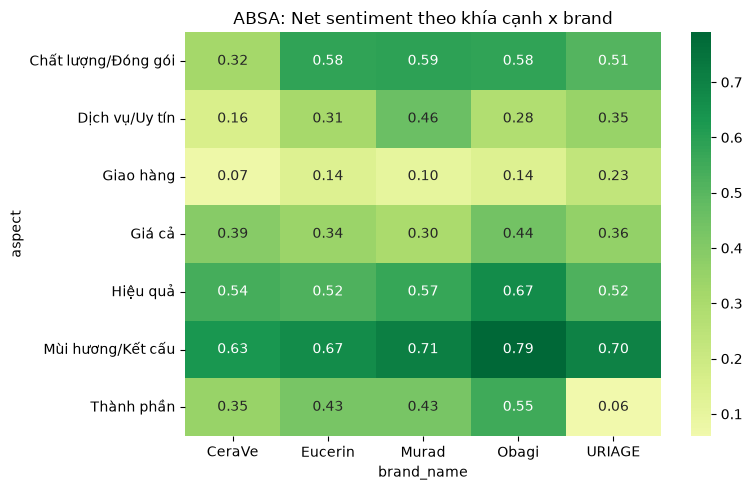

In [6]:
plt.figure(figsize=(8, 5))
sns.heatmap(absa_summary, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("ABSA: Net sentiment theo khía cạnh x brand")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/04_absa_aspect_sentiment_heatmap.png", dpi=140)
plt.show()

## 4. Complaint ẩn theo brand

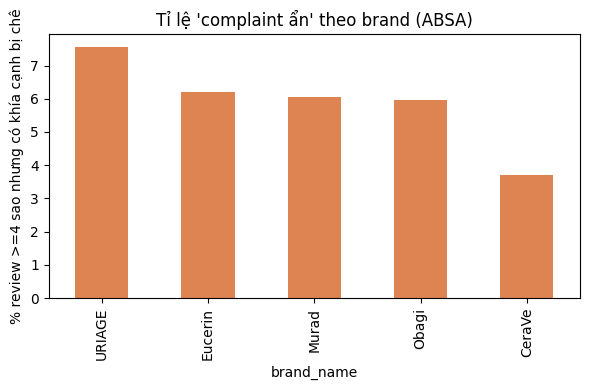


% complaint ẩn theo brand:
brand_name
URIAGE     7.6
Eucerin    6.2
Murad      6.0
Obagi      6.0
CeraVe     3.7
Name: hidden_complaint, dtype: float64


In [7]:
hidden_by_brand = review_summary.groupby("brand_name")["hidden_complaint"].mean().sort_values(
    ascending=False
) * 100
plt.figure(figsize=(6, 4))
hidden_by_brand.plot(kind="bar", color="#dd8452")
plt.ylabel("% review >=4 sao nhưng có khía cạnh bị chê")
plt.title("Tỉ lệ 'complaint ẩn' theo brand (ABSA)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/05_hidden_complaint_by_brand.png", dpi=140)
plt.show()
print("\n% complaint ẩn theo brand:")
print(hidden_by_brand.round(1))

## Hạn chế

Lexicon rule-based vẫn sai ở các ca phủ định phức tạp hơn "không/chẳng" —
ví dụ *"mất uy tín"* có thể bị chấm nhầm thành tích cực vì không nhận
diện "mất" là từ phủ định. Đây là giới hạn cố hữu của mọi phương pháp
rule-based (danh sách từ không bao giờ đủ) 